### Rupesh_koram (dz93614) 

In [4]:
!pip install pyspark

### 1.Creating a Spark session

In [5]:
from pyspark.sql import SparkSession

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import year, hour, col, when

spark = SparkSession.builder \
    .appName("Chicago Crime Analysis") \
    .getOrCreate()


23/10/19 00:58:06 WARN Utils: Your hostname, Rupeshs-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.0.0.144 instead (on interface en0)
23/10/19 00:58:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
23/10/19 00:58:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
23/10/19 00:58:08 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [7]:
spark

### 2. Define the schema for loading the Chicago crime dataset

In [9]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, TimestampType, FloatType
schema = StructType([StructField("ID", IntegerType(), True),
                     StructField("CaseNumber", StringType(), True),
                     StructField("Date", StringType(), True),
                     StructField("Block", StringType(), True),
                     StructField("IUCR", StringType(), True),
                     StructField("PrimaryType", StringType(), True),
                     StructField("Description", StringType(), True),
                     StructField("LocationDescription", StringType(), True),
                     StructField("Arrest", StringType(), True),
                     StructField("Domestic", StringType(), True),
                     StructField("Beat", IntegerType(), True),
                     StructField("District", IntegerType(), True),
                     StructField("Ward", IntegerType(), True),
                     StructField("CommunityArea", IntegerType(), True),
                     StructField("FBICode", StringType(), True),
                     StructField("XCoordinate", FloatType(), True),
                     StructField("YCoordinate", FloatType(), True),
                     StructField("Year", IntegerType(), True),
                     StructField("UpdatedOn", TimestampType(), True),
                     StructField("Latitude", FloatType(), True),
                     StructField("Longitude", FloatType(), True),
                     StructField("Location", StringType(), True)
])

---
### 3. Loading the Chicago crime data 

In [81]:
df = spark.read.csv('Crimes_-_2001_to_Present.csv', header=True)

In [82]:
df.count()

7912975

In [83]:
df.show(10)

+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
| 5741943|   HN549294|08/25/2007 09:22:...|  074XX N ROGERS AVE|0560|             ASSAULT|              SIMPLE|             

---
## 4. Cleaning the Data

### Step 1: Remove All Null Values



In [84]:
df = df.na.drop()

In [85]:
df.show(5)

+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|13210088|   JG423627|08/31/2023 12:00:...|023XX W JACKSON BLVD|1153|  DECEPTIVE PRACTICE|FINANCIAL IDENTIT...|             

In [86]:
df.count()

7208778

### Step 2: Changing 'Date' column data type

In [87]:
from pyspark.sql.functions import to_timestamp

df = df.withColumn("Date", to_timestamp("Date", 'MM/dd/yyyy hh:mm:ss a'))


In [88]:
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



---
##  5. Filter Data for the Last Ten Years

In [89]:
from pyspark.sql.functions import year, current_date, date_sub

ten_years = date_sub(current_date(), 10*365)  
df = df.filter(df["Date"] > ten_years_ago)


In [90]:
df.count()

2476314

---
### 6. Removing all the records with the following crime types:
* 'NON-CRIMINAL (SUBJECT SPECIFIED)'
* 'OTHER OFFENSE'
* 'STALKING'
* 'NON - CRIMINAL'
* 'ARSON' 

In [91]:
remove_crime = ['NON-CRIMINAL (SUBJECT SPECIFIED)', 'OTHER OFFENSE', 'STALKING', 'NON - CRIMINAL', 'ARSON']
df = df.filter(~col('Primary Type').isin(crime_to_remove))


In [92]:
df.count()

2312166

---
### Step 7: Merging Similar Crime Types

In [93]:
crime_mapping = {
    'SEX OFFENSE': 'SEX OFFENSE/PROSTITUTION',
    'PROSTITUTION': 'SEX OFFENSE/PROSTITUTION',
    'THEFT': 'THEFT/ROBBERY/BURGLARY',
    'BURGLARY': 'THEFT/ROBBERY/BURGLARY',
    'ROBBERY': 'THEFT/ROBBERY/BURGLARY',
    'ASSAULT': 'ASSAULT/BATTERY',
    'BATTERY': 'ASSAULT/BATTERY',
    'MOTOR VEHICLE THEFT': 'MOTOR VEHICLE THEFT/ARSON',
    'ARSON': 'MOTOR VEHICLE THEFT/ARSON',
    'CRIMINAL DAMAGE': 'CRIMINAL DAMAGE/TRESPASS',
    'CRIMINAL TRESPASS': 'CRIMINAL DAMAGE/TRESPASS',
}


In [94]:
from pyspark.sql.functions import udf

def map_crime(crime):
    return crime_mapping.get(crime, crime)

map_crime_udf = udf(map_crime)

df = df.withColumn('Primary Type', map_crime_udf(df['Primary Type']))


In [107]:
df.count()

2312166

---
## 8. Data Analysis and Presentation of Results

Now that our data is cleaned and pre-processed, it's time to dive deep into the analysis and extract meaningful insights.

### Analysis Objectives:

---



1. **Year-wise Crime Trend**:

In [95]:
from pyspark.sql.functions import count

y_crime_count = df.groupBy(year("Date").alias("Year")).agg(count("ID").alias("Count")).orderBy("Year")
yearly_counts.show()


+----+------+
|Year| Count|
+----+------+
|2013| 50847|
|2014|256123|
|2015|239889|
|2016|248588|
|2017|246560|
|2018|245377|
|2019|240849|
|2020|193864|
|2021|187553|
|2022|217411|
|2023|185105|
+----+------+



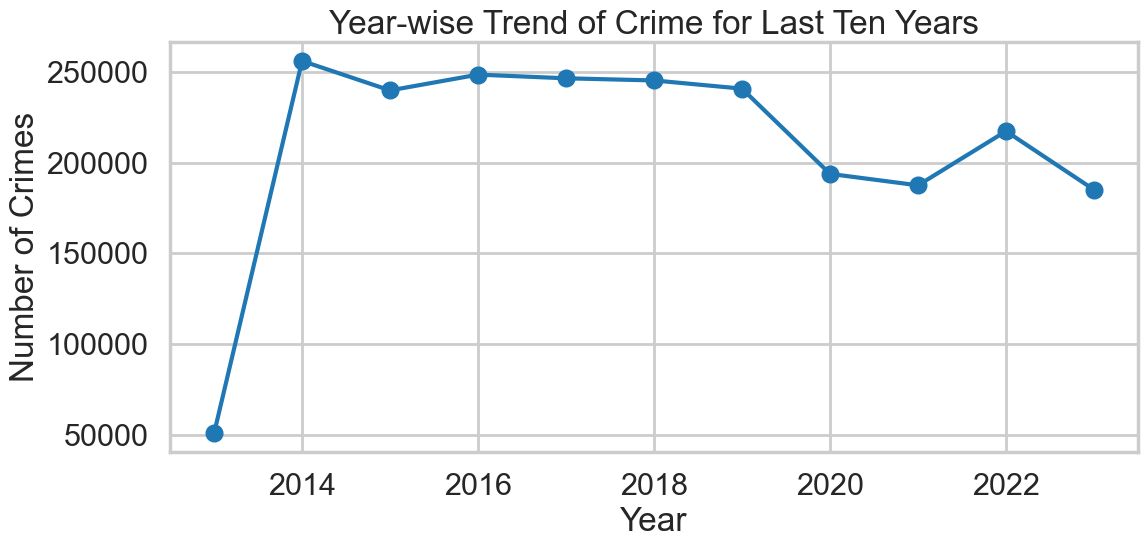

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
y_crime_count_pd = y_crime_count.toPandas()
plt.figure(figsize=(12, 6))
plt.plot(y_crime_count_pd["Year"], y_crime_count_pd["Count"], marker='o')
plt.title("Year-wise Trend of Crime for Last Ten Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid(True)
plt.tight_layout()
plt.show()


2. **Peak Crime Hours**:

In [97]:
from pyspark.sql.functions import hour

hour_counts = df.groupBy(hour("Date").alias("Hour")).agg(count("ID").alias("Count")).orderBy("Count", ascending=False)
hour_counts.show(10)



+----+------+
|Hour| Count|
+----+------+
|  12|133743|
|  18|130362|
|  19|128968|
|   0|126752|
|  15|126238|
|  17|125232|
|  20|123492|
|  16|122686|
|  21|115246|
|  14|115100|
+----+------+
only showing top 10 rows



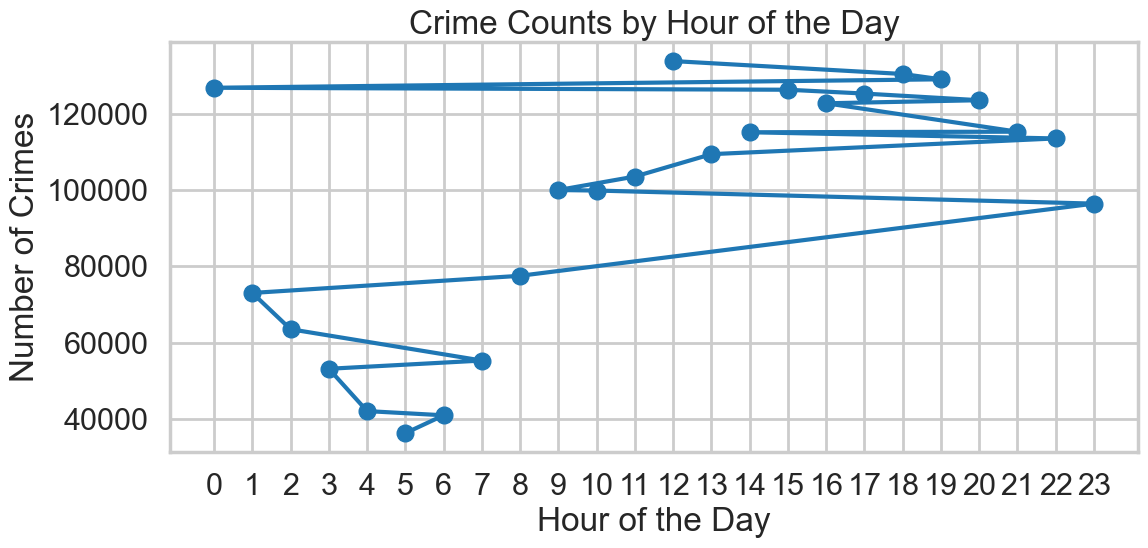

In [98]:
hour_counts_pd = hour_counts.toPandas()
plt.figure(figsize=(12, 6))
plt.plot(hour_counts_pd["Hour"], hour_counts_pd["Count"], marker='o')
plt.title("Crime Counts by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0, 24))  
plt.grid(True)
plt.tight_layout()
plt.show()


### At 12th hour Number of Crimes are 133743 (highest)
---

In [105]:
from pyspark.sql.functions import desc
df_groups = df.groupBy('Primary Type').count()
crime_type= df_groups.sort(desc('count')).limit(10)
crime_type_counts = crime_type.toPandas()

<function matplotlib.pyplot.show(close=None, block=None)>

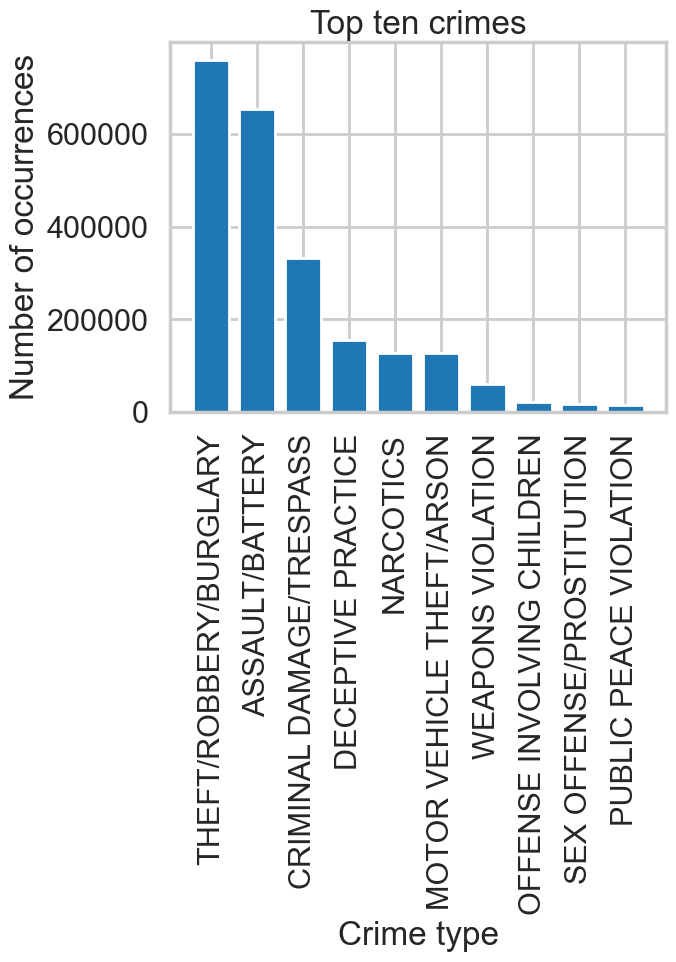

In [106]:
plt.bar(crime_type_counts['Primary Type'], crime_type_counts['count'])
plt.title('Top ten crimes')
plt.xlabel('Crime type')
plt.ylabel('Number of occurrences')
plt.xticks(rotation=90)
plt.show